# Кластеризация ЕГЭ (8.5 если сделаны все задачи)

Рядом лежат экселевские таблицы с координатами точек. В 3 и 4 задаче используется манхетеское расстояние. В остальных Евклидово.

* Постройте Распределение точек
* Кластеризуйте руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите усреднение центров всех кластеров * 1000

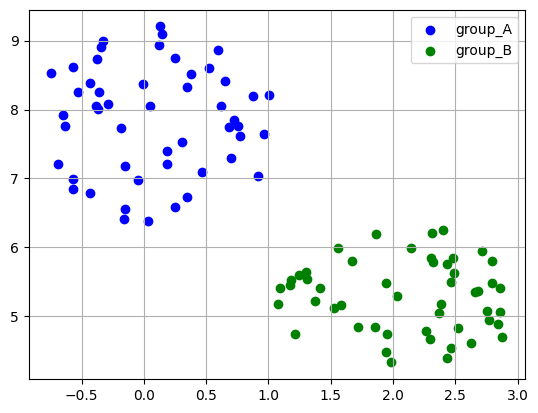

group_A: central point = [0.04811155 8.05305091]
group_A: centroid = [0.08026234 7.85281407]
group_B: central point = [2.033901  5.2892959]
group_B: centroid = [2.10667952 5.29860857]

Averaged centroid * 1000 = [1093.47092932 6575.71131612]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_excel("0.xls")

x_vals = np.array(data['X'])
y_vals = np.array(data['Y'])

slope = 3
intercept = 3

line_x = [-0.5, 3.0]
line_y = [slope * -0.5 + intercept, slope * 3.0 + intercept]

group_a_x = []
group_a_y = []
group_b_x = []
group_b_y = []

for idx in range(len(x_vals)):
    if y_vals[idx] > slope * x_vals[idx] + intercept:
        group_a_x.append(x_vals[idx])
        group_a_y.append(y_vals[idx])
    else:
        group_b_x.append(x_vals[idx])
        group_b_y.append(y_vals[idx])

plt.scatter(group_a_x, group_a_y, color="blue", label="group_A")
plt.scatter(group_b_x, group_b_y, color="green", label="group_B")

plt.grid(True)
plt.legend()
plt.show()

clusters_list = [
    (np.array([group_a_x, group_a_y]).T, "group_A"),
    (np.array([group_b_x, group_b_y]).T, "group_B")
]

all_means = []
for pts, label in clusters_list:
    if len(pts) > 0:
        best_dist = float('inf')
        center_pt = None
        for p_idx, pt in enumerate(pts):
            total_dist = np.sum(np.sqrt(np.sum((pts - pt) ** 2, axis=1)))
            if total_dist < best_dist:
                best_dist = total_dist
                center_pt = pt
        print(f"{label}: central point = {center_pt}")

        centroid = np.mean(pts, axis=0)
        all_means.append(centroid)
        print(f"{label}: centroid = {centroid}")

avg_centroid = np.mean(all_means, axis=0)
avg_scaled = avg_centroid * 1000
print(f"\nAveraged centroid * 1000 = {avg_scaled}")

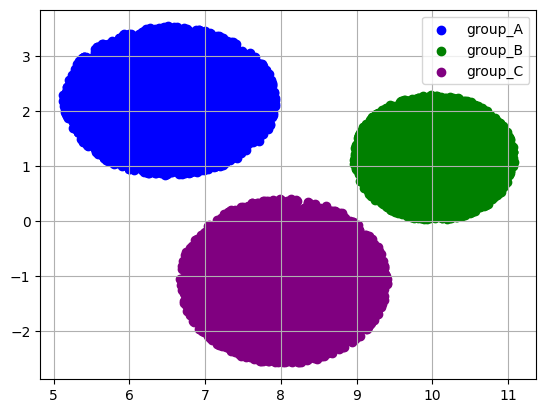

group_A: core point = [6.46998257 2.169761  ]
group_A: mean point = [6.51286131 2.1723648 ]
group_B: core point = [10.02253531  1.1542006 ]
group_B: mean point = [10.01809877  1.1702465 ]
group_C: core point = [ 8.04007453 -1.10870557]
group_C: mean point = [ 8.03064864 -1.11215642]

Scaled average mean * 1000 = [8187.20290544  743.48496005]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

excel_data = pd.read_excel("1.xls")

coord_x = np.array(excel_data['X'])
coord_y = np.array(excel_data['Y'])

m1 = 1
c1 = -6.8

m2 = -1.5
c2 = 14

lx1 = [5, 11]
ly1 = [m1 * 5 + c1, m1 * 11 + c1]

lx2 = [8, 11]
ly2 = [m2 * 8 + c2, m2 * 11 + c2]

part_a_x = []
part_a_y = []
part_b_x = []
part_b_y = []
part_c_x = []
part_c_y = []

for pos in range(len(coord_x)):
    if coord_y[pos] > m1 * coord_x[pos] + c1:
        part_a_x.append(coord_x[pos])
        part_a_y.append(coord_y[pos])
    elif coord_y[pos] > m2 * coord_x[pos] + c2:
        part_b_x.append(coord_x[pos])
        part_b_y.append(coord_y[pos])
    else:
        part_c_x.append(coord_x[pos])
        part_c_y.append(coord_y[pos])

plt.scatter(part_a_x, part_a_y, color="blue", label="group_A")
plt.scatter(part_b_x, part_b_y, color="green", label="group_B")
plt.scatter(part_c_x, part_c_y, color="purple", label="group_C")

plt.grid(True)
plt.legend()
plt.show()

groups = [
    (np.array([part_a_x, part_a_y]).T, "group_A"),
    (np.array([part_b_x, part_b_y]).T, "group_B"),
    (np.array([part_c_x, part_c_y]).T, "group_C")
]

all_means = []
for pts, label in groups:
    if len(pts) > 0:
        smallest_sum = float('inf')
        core_point = None
        for pid, pt in enumerate(pts):
            dsum = np.sum(np.sqrt(np.sum((pts - pt) ** 2, axis=1)))
            if dsum < smallest_sum:
                smallest_sum = dsum
                core_point = pt
        print(f"{label}: core point = {core_point}")

        mean_pt = np.mean(pts, axis=0)
        all_means.append(mean_pt)
        print(f"{label}: mean point = {mean_pt}")

avg_mean = np.mean(all_means, axis=0)
avg_mean_scaled = avg_mean * 1000
print(f"\nScaled average mean * 1000 = {avg_mean_scaled}")

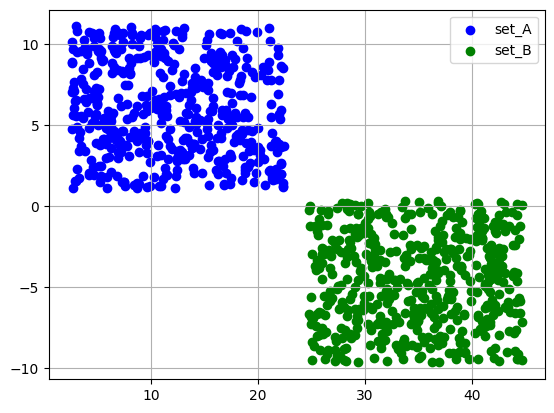

set_A: medoid point = [11.3340802   5.96596108]
set_A: centroid = [11.79914112  5.90797201]
set_B: medoid point = [34.92635132 -4.69527649]
set_B: centroid = [34.97637577 -4.61668646]

Scaled average centroid * 1000 = [23387.7584493    645.64277624]


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data_file = pd.read_excel("2.xlsx")

xs = np.array(data_file.iloc[:, 0])
ys = np.array(data_file.iloc[:, 1])

slope = 0
intercept = 0.5

horiz_line_x = [0, 45]
horiz_line_y = [slope * 0 + intercept, slope * 45 + intercept]

set_a_x = []
set_a_y = []
set_b_x = []
set_b_y = []

for idx in range(len(xs)):
    if ys[idx] > slope * xs[idx] + intercept:
        set_a_x.append(xs[idx])
        set_a_y.append(ys[idx])
    else:
        set_b_x.append(xs[idx])
        set_b_y.append(ys[idx])

plt.scatter(set_a_x, set_a_y, color="blue", label="set_A")
plt.scatter(set_b_x, set_b_y, color="green", label="set_B")

plt.grid(True)
plt.legend()
plt.show()

clusters_list = [
    (np.array([set_a_x, set_a_y]).T, "set_A"),
    (np.array([set_b_x, set_b_y]).T, "set_B")
]

all_centroids = []
for pts, label in clusters_list:
    if len(pts) > 0:
        best_dist = float('inf')
        medoid = None
        for pid, pt in enumerate(pts):
            total_dist = np.sum(np.sqrt(np.sum((pts - pt) ** 2, axis=1)))
            if total_dist < best_dist:
                best_dist = total_dist
                medoid = pt
        print(f"{label}: medoid point = {medoid}")

        centroid = np.mean(pts, axis=0)
        all_centroids.append(centroid)
        print(f"{label}: centroid = {centroid}")

avg_centroid = np.mean(all_centroids, axis=0)
avg_centroid_scaled = avg_centroid * 1000
print(f"\nScaled average centroid * 1000 = {avg_centroid_scaled}")

# Кластеризация (0.75 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [6]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

In [7]:
two_means = cluster.MiniBatchKMeans(init="k-means++", n_clusters=3, n_init=5, random_state=0)
dbscan = cluster.DBSCAN(eps=0.3)

clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("DBSCAN", dbscan),
    )

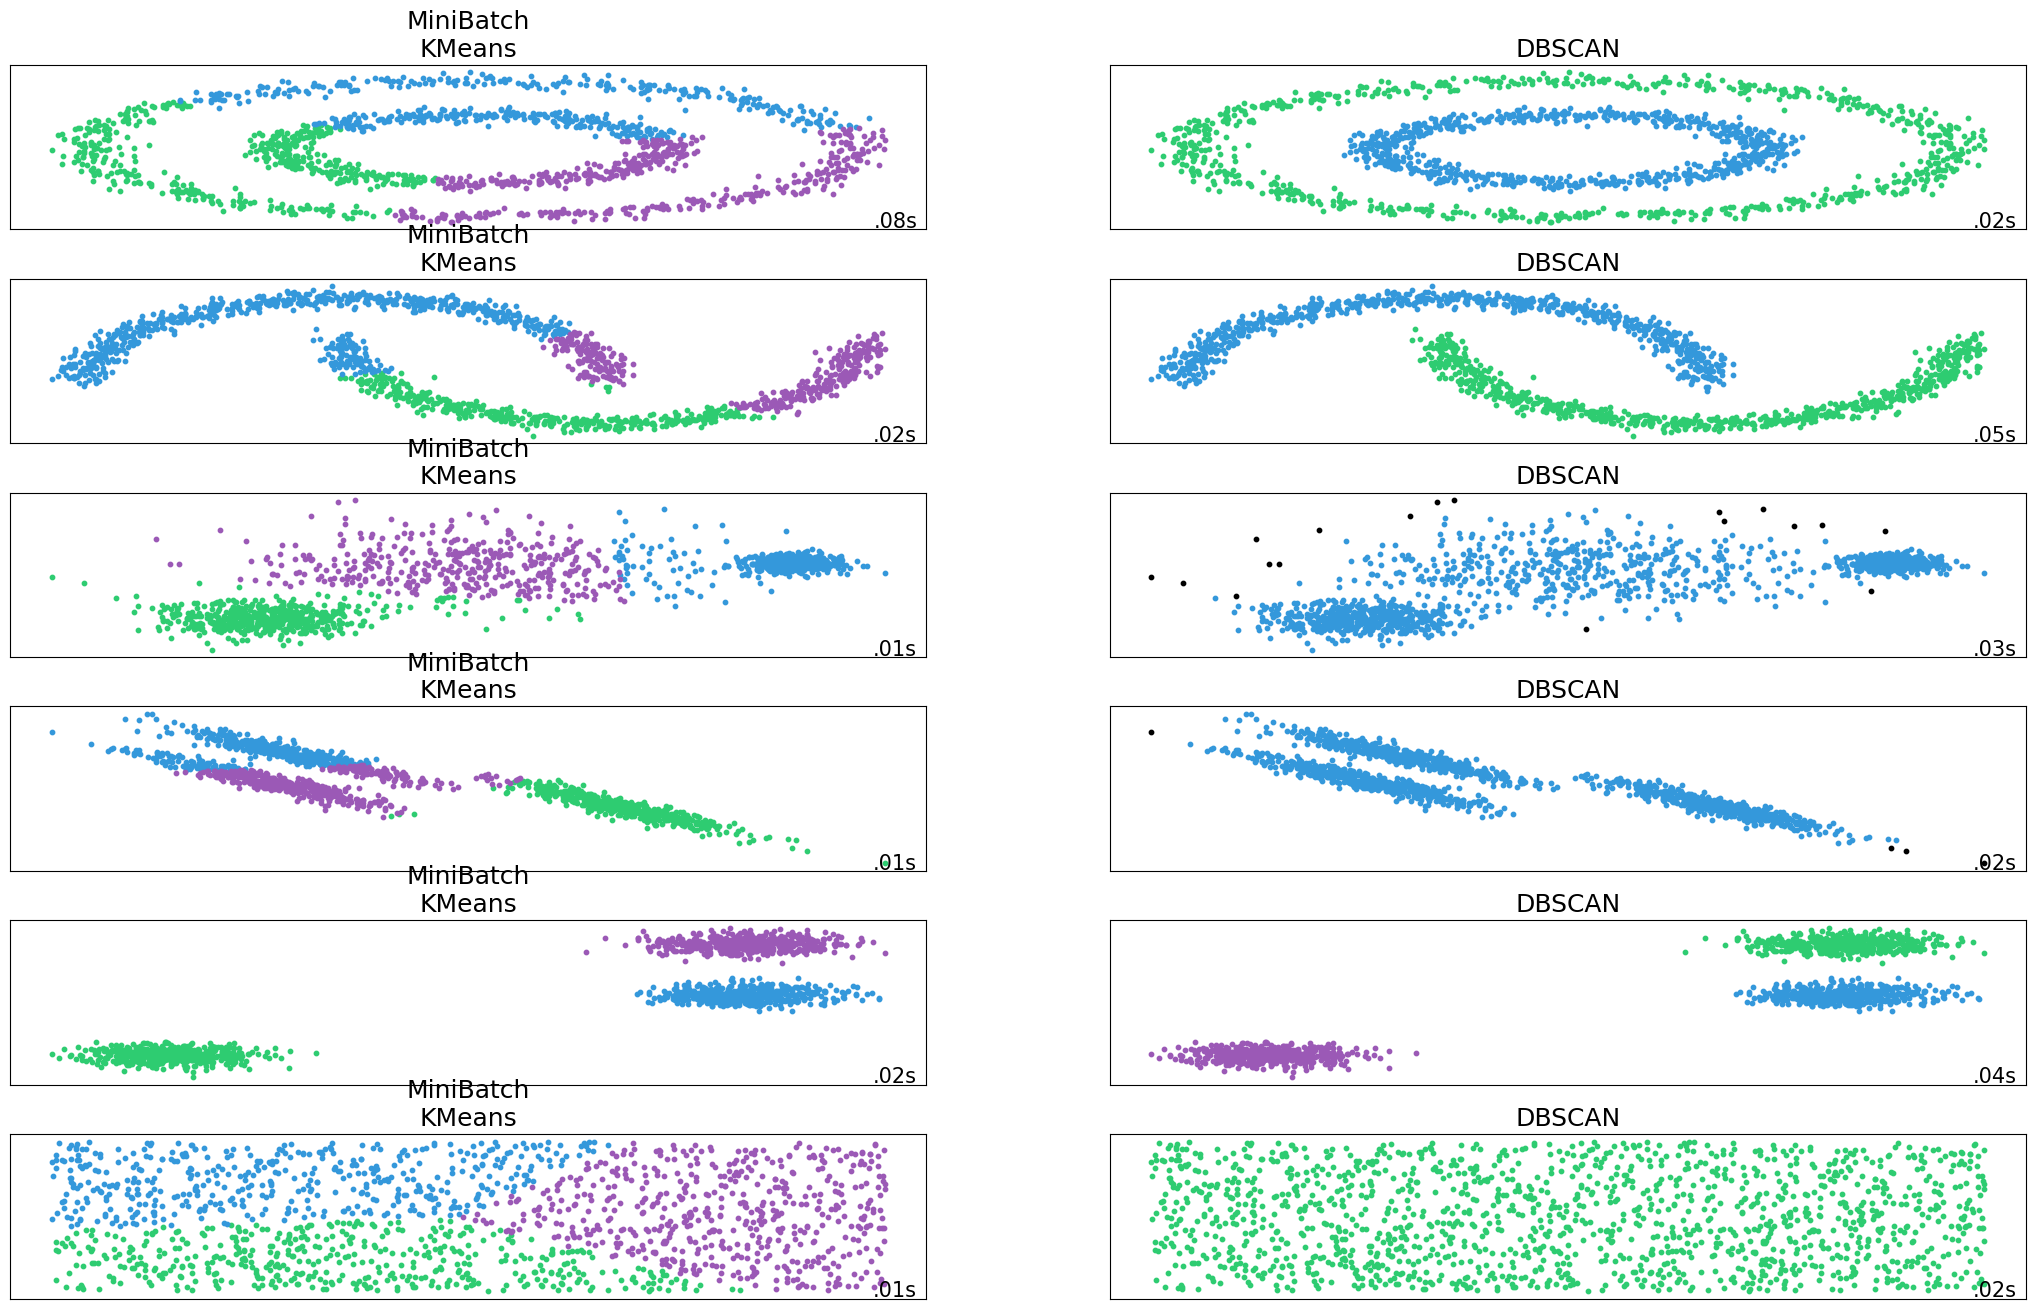

In [8]:
np.random.seed(0)
# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.2, hspace=0.3
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

datasets_list = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 20,
            "xi": 0.25,
        },
    ),
    (noisy_moons, {"damping": 0.75, "preference": -220, "n_clusters": 2}),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 5,
            "xi": 0.035,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 20,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets_list):
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    X = StandardScaler().fit_transform(X)

    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    connectivity = 0.5 * (connectivity + connectivity.T)

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        algorithm.fit(X)
        t1 = time.time()
        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(np.int64)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets_list), len(clustering_algorithms), plot_num)

        unique_labels = np.unique(y_pred)
        custom_colors = ['#2ecc71', '#3498db', '#9b59b6']  # green, blue, purple
        colors = [custom_colors[i % len(custom_colors)] for i in range(len(unique_labels))]

        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]

            class_member_mask = y_pred == k
            xy = X[class_member_mask]
            plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=10)

        plt.title(name, size=18)
        plt.xticks(())
        plt.yticks(())
        plt.text(0.99, 0.01, ("%.2fs" % (t1 - t0)).lstrip("0"), transform=plt.gca().transAxes, size=15, horizontalalignment="right")
        plot_num += 1

plt.show()